In [ ]:
# ============================================================
# SHORELINE KEMUJAN — HEADER
# Semua konstanta & setup. Satu-satunya tempat ngatur knob.
# ============================================================

import io, json, os, time
import numpy as np
import pandas as pd
import requests
import ee
import matplotlib.pyplot as plt

# ---------- GEE auth ----------
GEE_PROJECT = "gen-lang-client-0412358476"
ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)
print("EE initialized |", GEE_PROJECT)

# ---------- Path ----------
CONFIG_PATH = "../config/aoi.geojson"          # 18 AOI: Titik_01..Titik_18
MASK_DIR    = "../data/masks"                  # cache mask .npy per frame
TENSOR_DIR  = "../data/tensors"                # output tensor ConvLSTM
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(TENSOR_DIR, exist_ok=True)

# ---------- Sensor ----------
# Sentinel-2 only. Landsat DITOLAK sebagai input ConvLSTM (domain shift 30m vs
# 10m + perbedaan respons spektral). Landsat = konteks visual/kualitatif saja.
S2_SR_COLLECTION  = 'COPERNICUS/S2_SR_HARMONIZED'
S2_CLD_COLLECTION = 'COPERNICUS/S2_CLOUD_PROBABILITY'
SCALE_M = 10                                   # native Sentinel-2
import concurrent.futures
# ---------- Temporal: 3 musim x 4 bulan ----------
SEASONS = {
    'S1': ("01-01", "04-30"),                  # ekor Musim Barat
    'S2': ("05-01", "08-31"),                  # Musim Timur
    'S3': ("09-01", "12-31"),                  # transisi -> awal Musim Barat
}
SEASON_ORDER = ['S1', 'S2', 'S3']
YEARS        = list(range(2018, 2026))         # Sentinel-2 SR era
REF_YEAR     = 2022                            # sumber threshold Otsu per AOI

# ---------- Cloud/shadow masking ----------
CLOUD_FILTER   = 20      # buang scene >20% cloud (metadata)
CLD_PRB_THRESH = 50      # s2cloudless: prob >50% = awan
NIR_DRK_THRESH = 0.15    # B8 di bawah ini = kandidat dark pixel/shadow
CLD_PRJ_DIST   = 1       # jarak proyeksi shadow dari cloud (km)
BUFFER         = 50      # dilasi cloud mask (m)
MAX_WORKERS = 6
# ---------- Segmentasi & topologi ----------
CLOSING_RADIUS = 2       # morphological closing (px)
EDGE_ERODE_M   = 50      # buang edge palsu di tepi lingkaran AOI (m)
OCEAN_SEED_M   = 100     # tebal ring tepi AOI sebagai seed laut (m)
OCEAN_MAX_DIST = 5000    # jangkauan flood-fill laut dari seed (m)

# ---------- Dataset ConvLSTM ----------
PATCH_SIZE  = 128        # px native (BUKAN resize 512 — keputusan di-lock)
LOOKBACK    = 3          # sliding window: 3 frame -> prediksi frame ke-4
MIN_SCENE   = 5          # frame dgn scene < ini = rapuh, di-drop
TRAIN_UNTIL = 2022       # hindcast: target <= tahun ini masuk train

# ---------- Batch & rate limit GEE ----------
COOLDOWN_S = 8           # jeda antar frame (Community Tier)
BATCHES = [
    ['Titik_02', 'Titik_07', 'Titik_19'],   # wajib: erosion signal x2 + pulau cilik
    ['Titik_04', 'Titik_05', 'Titik_06'],
    ['Titik_09', 'Titik_10', 'Titik_11'],
]
# ---------- Visualisasi ----------
GRID_NCOLS      = 3
THUMB_DIMENSION = 512

# ---------- CATATAN: tide correction TIDAK di pipeline ----------
# pyTMD/EOT20 sudah dievaluasi terpisah. Hasil: korelasi tide vs pct_water
# tidak konsisten antar AOI, dan koreksi horizontal butuh slope pantai yang
# belum tersedia. Diputuskan: tidak diterapkan, dicatat sebagai limitation.

EE initialized | gen-lang-client-0412358476


In [ ]:
class ShorelineProcessor:
    """Satu instance = satu AOI. Produksi water mask per (tahun, musim).

    Threshold Otsu dihitung SEKALI dari composite referensi (Jan-Des REF_YEAR),
    lalu dipakai ke semua frame. Kalau tiap frame punya threshold sendiri,
    perubahan mask antar frame bisa datang dari drift threshold — bukan dari
    perubahan air — dan itu racun buat ConvLSTM.
    """

    def __init__(self, aoi_name, lon, lat, buffer_m=1000):
        self.aoi_name = aoi_name
        self.lon, self.lat = lon, lat
        self.buffer_m = buffer_m
        self.aoi = ee.Geometry.Point([lon, lat]).buffer(buffer_m)
        self.threshold = None       # ee.Number
        self.threshold_val = None   # float, buat log/laporan
        self.frames = {}            # (year, season) -> dict produk GEE
        self.meta = []              # riwayat: n_scene, status per frame

    def __repr__(self):
        t = "unfit" if self.threshold_val is None else f"thr={self.threshold_val:+.4f}"
        return f"<ShorelineProcessor {self.aoi_name} | {t} | {len(self.frames)} frame>"

    @classmethod
    def from_config(cls, config_path=CONFIG_PATH, aoi_names=None):
        cfg = json.load(open(config_path))
        names = aoi_names or list(cfg.keys())
        return {n: cls(n, cfg[n]['coord'][0], cfg[n]['coord'][1],
                       buffer_m=cfg[n]['buffer_m']) for n in names}

    # ---------- collection + masking ----------
    def _collection(self, start, end):
        s2 = (ee.ImageCollection(S2_SR_COLLECTION)
              .filterBounds(self.aoi).filterDate(start, end)
              .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))
        cld = (ee.ImageCollection(S2_CLD_COLLECTION)
               .filterBounds(self.aoi).filterDate(start, end))
        return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(
            primary=s2, secondary=cld,
            condition=ee.Filter.equals(leftField='system:index',
                                       rightField='system:index')))

    def _mask_clouds(self, img):
        cld_prb  = ee.Image(img.get('s2cloudless')).select('probability')
        is_cloud = cld_prb.gt(CLD_PRB_THRESH)
        not_water = img.select('SCL').neq(6)
        dark = img.select('B8').lt(NIR_DRK_THRESH * 1e4).multiply(not_water)
        azim = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')))
        proj = (is_cloud.directionalDistanceTransform(azim, CLD_PRJ_DIST * 10)
                .reproject(crs=img.select(0).projection(), scale=100)
                .select('distance').mask())
        shadows = proj.multiply(dark)
        cldshdw = (is_cloud.add(shadows).gt(0)
                   .focalMin(2).focalMax(BUFFER * 2 / 20)
                   .reproject(crs=img.select(0).projection(), scale=20))
        return img.select('B.*').updateMask(cldshdw.Not())

    @staticmethod
    def _add_mndwi(img):
        """B11 (20m) resample bilinear ke grid 10m sebelum dikombinasi dgn B3.
        Tanpa ini, transisi darat-air ngikutin kotak grid 20m (staircase)."""
        b3 = img.select('B3')
        b11 = (img.select('B11').resample('bilinear')
               .reproject(crs=b3.projection(), scale=SCALE_M))
        return img.addBands(b3.subtract(b11).divide(b3.add(b11)).rename('MNDWI'))

    def _composite_retry(self, start, end, max_retry=3):
        for attempt in range(max_retry):
            try:
                return self._composite(start, end)
            except Exception as e:
                if attempt == max_retry - 1:
                    raise
                wait = 20 * (attempt + 1)
                print(f"    retry {attempt+1}/{max_retry} setelah {wait}s ({type(e).__name__})")
                time.sleep(wait)
                
                
    def _composite(self, start, end):
        coll = self._collection(start, end)
        n = coll.size().getInfo()
        if n == 0:
            return None, 0
        comp = (coll.map(self._mask_clouds).map(self._add_mndwi)
                    .median().clip(self.aoi))
        return comp, n

    # ---------- Otsu ----------
    @staticmethod
    def _otsu(histogram):
        counts = ee.Array(ee.Dictionary(histogram).get('histogram'))
        means  = ee.Array(ee.Dictionary(histogram).get('bucketMeans'))
        size   = means.length().get([0])
        total  = counts.reduce(ee.Reducer.sum(), [0]).get([0])
        sum_   = means.multiply(counts).reduce(ee.Reducer.sum(), [0]).get([0])
        mean   = sum_.divide(total)

        def bss(i):
            a_counts = counts.slice(0, 0, i)
            a_count  = a_counts.reduce(ee.Reducer.sum(), [0]).get([0])
            a_means  = means.slice(0, 0, i)
            a_mean   = (a_means.multiply(a_counts).reduce(ee.Reducer.sum(), [0])
                        .get([0]).divide(a_count))
            b_count  = total.subtract(a_count)
            b_mean   = sum_.subtract(a_count.multiply(a_mean)).divide(b_count)
            return (a_count.multiply(a_mean.subtract(mean).pow(2))
                    .add(b_count.multiply(b_mean.subtract(mean).pow(2))))

        bss_values = ee.List.sequence(1, size).map(lambda i: bss(ee.Number(i)))
        return means.sort(bss_values).get([-1])

    def fit_threshold(self, ref_year=REF_YEAR, verbose=True):
        """Otsu sekali dari composite Jan-Des ref_year. WAJIB sebelum process()."""
        comp, n = self._composite(f"{ref_year}-01-01", f"{ref_year}-12-31")
        if comp is None:
            raise RuntimeError(f"[{self.aoi_name}] tidak ada scene di {ref_year}")
        hist = comp.select('MNDWI').reduceRegion(
            reducer=ee.Reducer.histogram(255, 0.01),
            geometry=self.aoi, scale=SCALE_M, maxPixels=1e9).get('MNDWI')
        self.threshold = self._otsu(hist)
        self.threshold_val = self.threshold.getInfo()
        if verbose:
            print(f"[{self.aoi_name}] threshold Otsu ({ref_year}, {n} scene) "
                  f"= {self.threshold_val:+.4f}")
        return self.threshold_val

    # ---------- segmentasi + topologi ----------
    def _water_mask(self, comp):
        water = comp.select('MNDWI').gt(self.threshold)
        proj  = comp.select('MNDWI').projection()
        return (water
                .focalMode(radius=1, kernelType='square', units='pixels')
                .focalMax(CLOSING_RADIUS, kernelType='square', units='pixels')
                .focalMin(CLOSING_RADIUS, kernelType='square', units='pixels')
                .reproject(crs=proj, scale=SCALE_M)
                .rename('water'))

    def _keep_ocean(self, water):
        """Laut = air yang terhubung ke TEPI AOI (bukan komponen terbesar).
        Kriteria ukuran gagal di AOI tanjung/pulau: laut bisa pecah jadi 2 sisi
        yang dua-duanya asli. Flood-fill dari ring tepi lewat pixel air saja;
        kolam pedalaman yang dikelilingi darat tidak terjangkau -> dibuang."""
        aoi_mask = ee.Image.constant(1).clip(self.aoi).mask()
        inner    = aoi_mask.focalMin(radius=OCEAN_SEED_M, units='meters')
        ring     = aoi_mask.subtract(inner)              # cincin tepi AOI
        seed     = water.multiply(ring).selfMask()       # air yang nyentuh tepi
        cost     = water.Not().multiply(1e6).add(1)      # air murah, darat mahal
        reach    = cost.cumulativeCost(source=seed, maxDistance=OCEAN_MAX_DIST)
        return water.updateMask(reach.lt(1e5)).unmask(0).rename('water')

    def _edge(self, water):
        """Edge 1-px, buang yang nempel tepi AOI. Erosi dilakukan di RASTER
        (focalMin pada mask), bukan negative buffer geometry — geometry negatif
        bisa degenerate dan bikin clip menghasilkan kosong."""
        e = water.subtract(water.focalMin(1, units='pixels')).selfMask()
        interior = (ee.Image.constant(1).clip(self.aoi).mask()
                    .focalMin(radius=EDGE_ERODE_M, units='meters'))
        return e.updateMask(interior).rename('shoreline')

    # ---------- entry point ----------
    def process(self, years=YEARS, seasons=SEASONS, cooldown_s=COOLDOWN_S,
                verbose=False, show_progress=True):
        if self.threshold is None:
            raise RuntimeError(f"[{self.aoi_name}] fit_threshold() dulu")

        # flatten jadi list (yr, season) biar tqdm tau total-nya
        todo = [(yr, s) for yr in years for s in SEASON_ORDER
                if s in seasons and (yr, s) not in self.frames]

        bar = tqdm(todo, desc=f"{self.aoi_name}", unit="frame",
                   leave=False, disable=not show_progress)
        n_ok = n_thin = n_empty = 0

        for yr, s_name in bar:
            s_md, e_md = seasons[s_name]
            comp, n = self._composite_retry(f"{yr}-{s_md}", f"{yr}-{e_md}")

            if comp is None:
                n_empty += 1
                self.meta.append({'year': yr, 'season': s_name,
                                  'n_scene': 0, 'status': 'empty'})
                bar.set_postfix(ok=n_ok, thin=n_thin, empty=n_empty, refresh=False)
                time.sleep(2); continue

            if n < MIN_SCENE:
                n_thin += 1
                self.meta.append({'year': yr, 'season': s_name,
                                  'n_scene': n, 'status': 'thin'})
                bar.set_postfix(ok=n_ok, thin=n_thin, empty=n_empty, refresh=False)
                time.sleep(2); continue

            water = self._keep_ocean(self._water_mask(comp))
            self.frames[(yr, s_name)] = {
                'composite': comp, 'water': water, 'edge': self._edge(water),
                'n_scene': n}
            n_ok += 1
            self.meta.append({'year': yr, 'season': s_name,
                              'n_scene': n, 'status': 'ok'})
            bar.set_postfix(ok=n_ok, thin=n_thin, empty=n_empty, refresh=False)
            if verbose:
                tqdm.write(f"  {yr}-{s_name}: {n} scene")
            time.sleep(cooldown_s)

        bar.close()
        df = pd.DataFrame(self.meta).drop_duplicates(
            subset=['year', 'season'], keep='last')
        return self.frames, df

    # ---------- QA visual ----------
    def visualize(self, year, season, zoom=14):
        import geemap
        f = self.frames[(year, season)]
        m = geemap.Map(center=[self.lat, self.lon], zoom=zoom)
        m.add_basemap("SATELLITE")
        m.addLayer(f['composite'], {'bands': ['B4','B3','B2'], 'min':0,
                                    'max':2500, 'gamma':1.1}, 'RGB', True)
        m.addLayer(f['water'].selfMask(), {'palette': ['#2166ac']}, 'water', False)
        m.addLayer(f['edge'], {'palette': ['#e31a1c']}, 'shoreline', True)
        m.addLayer(self.aoi, {'color': 'yellow'}, 'AOI')
        m.addLayerControl()
        return m

In [3]:
from tqdm.auto import tqdm   # kalau belum: pip install tqdm

In [4]:
BATCH_STATE_PATH = os.path.join(TENSOR_DIR, "batch_progress.json")

In [ ]:
class ShorelineOrchestrator:
    """Multi AOI x tahun x musim -> tensor ConvLSTM.

    Alur: run_all() -> export_all() -> build_tensor() -> temporal_split()
    Frame urut kronologis: (2018,S1),(2018,S2),(2018,S3),(2019,S1),...
    Window LOOKBACK frame -> prediksi frame berikutnya.
    """

    def __init__(self, config_path=CONFIG_PATH, mask_dir=MASK_DIR,
                 tensor_dir=TENSOR_DIR):
        self.config_path = config_path
        self.mask_dir = mask_dir
        self.tensor_dir = tensor_dir
        self.processors = {}                 # aoi_name -> ShorelineProcessor
        self.masks = {}                      # aoi_name -> {(yr,season): np.ndarray}
        self.X = self.y = self.meta = None

    # ---------- 1. preprocessing ----------
    def run_all(self, aoi_names, years=YEARS, ref_year=REF_YEAR):
        procs = ShorelineProcessor.from_config(self.config_path, aoi_names)
        bar = tqdm(procs.items(), desc="AOI", unit="aoi")
        for nama, p in bar:
            bar.set_postfix_str(nama, refresh=True)
            try:
                p.fit_threshold(ref_year, verbose=False)
                _, df = p.process(years)
                ok    = (df.status == 'ok').sum()
                thin  = (df.status == 'thin').sum()
                empty = (df.status == 'empty').sum()
                tqdm.write(f"✓ {nama:10s} thr={p.threshold_val:+.4f} | "
                           f"ok={ok:2d} thin={thin} empty={empty}")
                self.processors[nama] = p
            except Exception as e:
                tqdm.write(f"✗ {nama:10s} GAGAL: {type(e).__name__}: {e}")
            time.sleep(30)
        bar.close()
        return self.processors

    # ---------- checkpoint per-batch ----------
    def _batch_state_path(self):
        return os.path.join(self.tensor_dir, "batch_progress.json")

    def _load_batch_progress(self):
        path = self._batch_state_path()
        if os.path.exists(path):
            return json.load(open(path))
        return {"completed_batches": []}

    def _save_batch_progress(self, state):
        with open(self._batch_state_path(), "w") as f:
            json.dump(state, f, indent=2)

    def run_next_batch(self, batches, ref_year=REF_YEAR):
        """Proses SATU batch yang belum selesai, lalu stop. Progress disimpen
        ke disk -- aman lintas re-run cell. Panggil ulang buat lanjut."""
        state = self._load_batch_progress()
        done_idx = set(state["completed_batches"])

        next_i, next_batch = None, None
        for i, batch in enumerate(batches, 1):
            if i not in done_idx:
                next_i, next_batch = i, batch
                break

        if next_batch is None:
            print("Semua batch sudah diproses. Tinggal panggil export_offline().")
            return "done"

        print(f"\n{'='*50}\nBATCH {next_i}/{len(batches)}: {next_batch}\n{'='*50}")
        self.run_all(next_batch, ref_year=ref_year)
        self.export_all()
        print(self.summary())

        state["completed_batches"].append(next_i)
        self._save_batch_progress(state)

        sisa = len(batches) - len(state["completed_batches"])
        if sisa > 0:
            print(f"\n✓ Batch {next_i} selesai. Sisa {sisa} batch. Cek kuota EECU dulu.")
            return "continue"
        else:
            print(f"\n✓ Batch {next_i} (terakhir) selesai. Semua batch kelar!")
            return "all_done"

    def reset_batch_progress(self):
        path = self._batch_state_path()
        if os.path.exists(path):
            os.remove(path)
            print(f"Checkpoint dihapus: {path}")
        else:
            print("Belum ada checkpoint.")

    def export_all(self, force=False, max_workers=MAX_WORKERS):
        total = sum(len(p.frames) for p in self.processors.values())
        bar = tqdm(total=total, desc="export", unit="mask")

        def _download_one(nama, yr, s, f, region, out):
            path = os.path.join(out, f"{yr}_{s}.npy")
            if os.path.exists(path) and not force:
                return nama, (yr, s), np.load(path), "cache"
            url = f['water'].getDownloadURL({
                'region': region, 'scale': SCALE_M, 'format': 'NPY'})
            r = requests.get(url); r.raise_for_status()
            m = self._fit_patch(np.load(io.BytesIO(r.content))['water']
                                .astype(np.float32))
            np.save(path, m)
            return nama, (yr, s), m, "new"

        jobs = []
        for nama, p in self.processors.items():
            out = os.path.join(self.mask_dir, nama)
            os.makedirs(out, exist_ok=True)
            self.masks.setdefault(nama, {})
            region = self._patch_region(p)
            for (yr, s), f in sorted(p.frames.items()):
                jobs.append((nama, yr, s, f, region, out))

        counts = {}
        with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = {ex.submit(_download_one, *j): j for j in jobs}
            for fut in concurrent.futures.as_completed(futures):
                nama, yr, s, f, region, out = futures[fut]
                try:
                    nama_r, key, m, status = fut.result()
                    self.masks[nama_r][key] = m
                    counts.setdefault(nama_r, {'new': 0, 'cache': 0})
                    counts[nama_r][status] += 1
                except Exception as e:
                    tqdm.write(f"✗ {nama} {yr}-{s} GAGAL: {type(e).__name__}: {e}")
                bar.update(1)
                bar.set_postfix_str(nama, refresh=False)

        bar.close()
        for nama, c in counts.items():
            tqdm.write(f"✓ {nama:10s} {c['new']} baru, {c['cache']} dari cache")
        return self.masks

    def summary(self):
        rows = []
        for nama, p in self.processors.items():
            df = pd.DataFrame(p.meta).drop_duplicates(['year','season'], keep='last')
            rows.append({
                'aoi': nama,
                'threshold': round(p.threshold_val, 4),
                'ok': int((df.status=='ok').sum()),
                'thin': int((df.status=='thin').sum()),
                'empty': int((df.status=='empty').sum()),
                'mask_exported': len(self.masks.get(nama, {})),
            })
        return pd.DataFrame(rows).set_index('aoi')

    def _patch_region(self, p):
        half_m = PATCH_SIZE * SCALE_M / 2
        return ee.Geometry.Point([p.lon, p.lat]).buffer(half_m).bounds()

    @staticmethod
    def _fit_patch(mask):
        t = PATCH_SIZE
        h, w = mask.shape
        if h > t:
            mask = mask[(h - t)//2:(h - t)//2 + t, :]
        if w > t:
            mask = mask[:, (w - t)//2:(w - t)//2 + t]
        h, w = mask.shape
        if h < t or w < t:
            pad = np.zeros((t, t), dtype=mask.dtype)
            pad[:h, :w] = mask
            mask = pad
        return mask

    @staticmethod
    def _seq_index(yr, s):
        return yr * 3 + SEASON_ORDER.index(s)

    def build_tensor(self):
        X_list, y_list, meta = [], [], []
        for nama, frames in self.masks.items():
            keys = sorted(frames.keys(), key=lambda k: self._seq_index(*k))
            for i in range(len(keys) - LOOKBACK):
                win    = keys[i:i + LOOKBACK]
                target = keys[i + LOOKBACK]
                idx = [self._seq_index(*k) for k in win + [target]]
                if idx != list(range(idx[0], idx[0] + LOOKBACK + 1)):
                    continue
                X_list.append(np.stack([frames[k][np.newaxis] for k in win]))
                y_list.append(frames[target][np.newaxis])
                meta.append({'aoi': nama, 'input': win, 'target': target,
                             'target_year': target[0]})

        self.X = np.stack(X_list)
        self.y = np.stack(y_list)
        self.meta = meta
        print(f"\nTensor: X{self.X.shape} y{self.y.shape} | {len(meta)} sample "
              f"dari {len(self.masks)} AOI")
        return self.X, self.y, meta

    def temporal_split(self, train_until=TRAIN_UNTIL, save=True):
        tr = [i for i, m in enumerate(self.meta) if m['target_year'] <= train_until]
        te = [i for i, m in enumerate(self.meta) if m['target_year'] >  train_until]
        split = {'X_train': self.X[tr], 'y_train': self.y[tr],
                 'X_test':  self.X[te], 'y_test':  self.y[te],
                 'meta_train': [self.meta[i] for i in tr],
                 'meta_test':  [self.meta[i] for i in te]}
        print(f"train: {len(tr)} sample (target <= {train_until}) | "
              f"test: {len(te)} sample")
        if save:
            path = os.path.join(self.tensor_dir, f"convlstm_until{train_until}.npz")
            np.savez_compressed(path, X_train=split['X_train'], y_train=split['y_train'],
                                X_test=split['X_test'], y_test=split['y_test'])
            print(f"saved: {path}")
        return split

    def show_frames(self, aoi_name, ncols=6):
        frames = self.masks[aoi_name]
        keys = sorted(frames.keys(), key=lambda k: self._seq_index(*k))
        nrows = -(-len(keys) // ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(2.1*ncols, 2.4*nrows))
        axes = np.atleast_1d(axes).flatten()
        for ax, k in zip(axes, keys):
            m = frames[k]
            ax.imshow(m, cmap='Blues', vmin=0, vmax=1)
            ax.set_title(f"{k[0]}-{k[1]}\n{m.mean()*100:.0f}%", fontsize=7)
            ax.axis('off')
        for ax in axes[len(keys):]:
            ax.axis('off')
        plt.suptitle(aoi_name); plt.tight_layout(); plt.show()

    def water_pct_table(self, aoi_name):
        frames = self.masks[aoi_name]
        rows = [{'year': k[0], 'season': k[1], 'water_pct': v.mean()*100}
                for k, v in sorted(frames.items(), key=lambda x: self._seq_index(*x[0]))]
        df = pd.DataFrame(rows)
        df['delta_pp'] = df['water_pct'].diff()
        return df

    def export_offline(self, out_dir=None, bundle=True):
        out_dir = out_dir or os.path.join(self.tensor_dir, "offline")
        os.makedirs(out_dir, exist_ok=True)

        manifest = {
            "created_utc": pd.Timestamp.utcnow().isoformat(),
            "gee_project": GEE_PROJECT,
            "source": {
                "s2_sr": S2_SR_COLLECTION,
                "s2_cloud": S2_CLD_COLLECTION,
                "scale_m": SCALE_M,
                "note": "Sentinel-2 only. Landsat ditolak: domain shift 30m vs 10m.",
            },
            "params": {
                "CLOUD_FILTER": CLOUD_FILTER,
                "CLD_PRB_THRESH": CLD_PRB_THRESH,
                "NIR_DRK_THRESH": NIR_DRK_THRESH,
                "CLD_PRJ_DIST": CLD_PRJ_DIST,
                "BUFFER": BUFFER,
                "CLOSING_RADIUS": CLOSING_RADIUS,
                "EDGE_ERODE_M": EDGE_ERODE_M,
                "OCEAN_SEED_M": OCEAN_SEED_M,
                "PATCH_SIZE": PATCH_SIZE,
                "MIN_SCENE": MIN_SCENE,
                "REF_YEAR": REF_YEAR,
                "SEASONS": SEASONS,
            },
            "aoi": {},
        }
        for nama, p in self.processors.items():
            manifest["aoi"][nama] = {
                "lon": p.lon,
                "lat": p.lat,
                "buffer_m": p.buffer_m,
                "threshold_otsu": p.threshold_val,
                "threshold_ref_year": REF_YEAR,
                "frames": {
                    f"{k[0]}_{k[1]}": v["n_scene"] for k, v in sorted(p.frames.items())
                },
            }

        with open(os.path.join(out_dir, "manifest.json"), "w") as f:
            json.dump(manifest, f, indent=2)

        for nama, frames in self.masks.items():
            arrays = {f"{k[0]}_{k[1]}": v for k, v in frames.items()}
            np.savez_compressed(os.path.join(out_dir, f"{nama}_masks.npz"), **arrays)

        rows = []
        for nama, p in self.processors.items():
            for (yr, s), fr in sorted(p.frames.items()):
                rows.append({
                    "aoi": nama, "year": yr, "season": s,
                    "n_scene": fr["n_scene"], "threshold": p.threshold_val,
                })
        pd.DataFrame(rows).to_csv(os.path.join(out_dir, "frames_summary.csv"), index=False)

        size_mb = (sum(os.path.getsize(os.path.join(out_dir, f))
                       for f in os.listdir(out_dir)) / 1e6)
        print(f"Offline bundle: {out_dir} | {len(self.masks)} AOI | {size_mb:.1f} MB")

        if bundle:
            import shutil
            zip_path = shutil.make_archive(out_dir, "zip", out_dir)
            print(f"Zip siap upload: {zip_path} ({os.path.getsize(zip_path)/1e6:.1f} MB)")
        return out_dir

    @staticmethod
    def load_offline(bundle_dir):
        with open(os.path.join(bundle_dir, "manifest.json")) as f:
            manifest = json.load(f)
        masks = {}
        for fn in os.listdir(bundle_dir):
            if not fn.endswith("_masks.npz"):
                continue
            nama = fn.replace("_masks.npz", "")
            z = np.load(os.path.join(bundle_dir, fn))
            masks[nama] = {(int(k.split("_")[0]), k.split("_")[1]): z[k] for k in z.files}
        print(f"Loaded {len(masks)} AOI dari {bundle_dir} (dibuat {manifest['created_utc'][:10]})")
        return masks, manifest

In [6]:
# --- SANITY CHECK: 1 AOI aja dulu, buat cek pipeline jalan + lihat EECU cost riil ---
sanity = ShorelineOrchestrator()
sanity.run_all(['Titik_02'])       # AOI prioritas, paling kecil resiko-nya kalau gagal
sanity.export_all()
print(sanity.summary())

AOI:   0%|          | 0/1 [00:00<?, ?aoi/s]

Titik_02:   0%|          | 0/24 [00:00<?, ?frame/s]

✓ Titik_02   thr=+0.0047 | ok=14 thin=7 empty=3


export:   0%|          | 0/14 [00:00<?, ?mask/s]

✓ Titik_02   1 baru, 13 dari cache
          threshold  ok  thin  empty  mask_exported
aoi                                                
Titik_02     0.0047  14     7      3             14


In [7]:
orch = ShorelineOrchestrator()

while True:
    status = orch.run_next_batch(BATCHES)
    if status in ("done", "all_done"):
        break

orch.export_offline()


BATCH 1/3: ['Titik_02', 'Titik_07', 'Titik_19']


AOI:   0%|          | 0/3 [00:00<?, ?aoi/s]

Titik_02:   0%|          | 0/24 [00:00<?, ?frame/s]

✓ Titik_02   thr=+0.0047 | ok=14 thin=7 empty=3


Titik_07:   0%|          | 0/24 [00:00<?, ?frame/s]

...

✓ Titik_11   thr=+0.0946 | ok=15 thin=6 empty=3


export:   0%|          | 0/129 [00:00<?, ?mask/s]

✓ Titik_02   0 baru, 14 dari cache
✓ Titik_07   0 baru, 14 dari cache
✓ Titik_19   0 baru, 14 dari cache
✓ Titik_04   0 baru, 14 dari cache
✓ Titik_05   0 baru, 15 dari cache
✓ Titik_06   0 baru, 14 dari cache
✓ Titik_09   14 baru, 0 dari cache
✓ Titik_10   15 baru, 0 dari cache
✓ Titik_11   15 baru, 0 dari cache
          threshold  ok  thin  empty  mask_exported
aoi                                                
Titik_02     0.0047  14     7      3             14
Titik_07    -0.0554  14     7      3             14
Titik_19     0.4551  14     7      3             14
Titik_04    -0.0863  14     7      3             14
Titik_05     0.0346  15     6      3             15
Titik_06    -0.0449  14     7      3             14
Titik_09     0.0956  14     7      3             14
Titik_10    -0.0150  15     6      3             15
Titik_11     0.0946  15     6      3             15

✓ Batch 3 (terakhir) selesai. Semua batch kelar!
Offline bundle: ../data/tensors\offline | 9 AOI | 0.1 MB
Zip si

C:\Users\Loq Gaming\AppData\Local\Temp\ipykernel_24276\3020099754.py:241: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "created_utc": pd.Timestamp.utcnow().isoformat(),


'../data/tensors\\offline'

In [8]:
orch.export_offline()

C:\Users\Loq Gaming\AppData\Local\Temp\ipykernel_24276\3020099754.py:241: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "created_utc": pd.Timestamp.utcnow().isoformat(),


Offline bundle: ../data/tensors\offline | 9 AOI | 0.1 MB
Zip siap upload: e:\PROKER KKN\shoreline-kemujan\data\tensors\offline.zip (0.0 MB)


'../data/tensors\\offline'

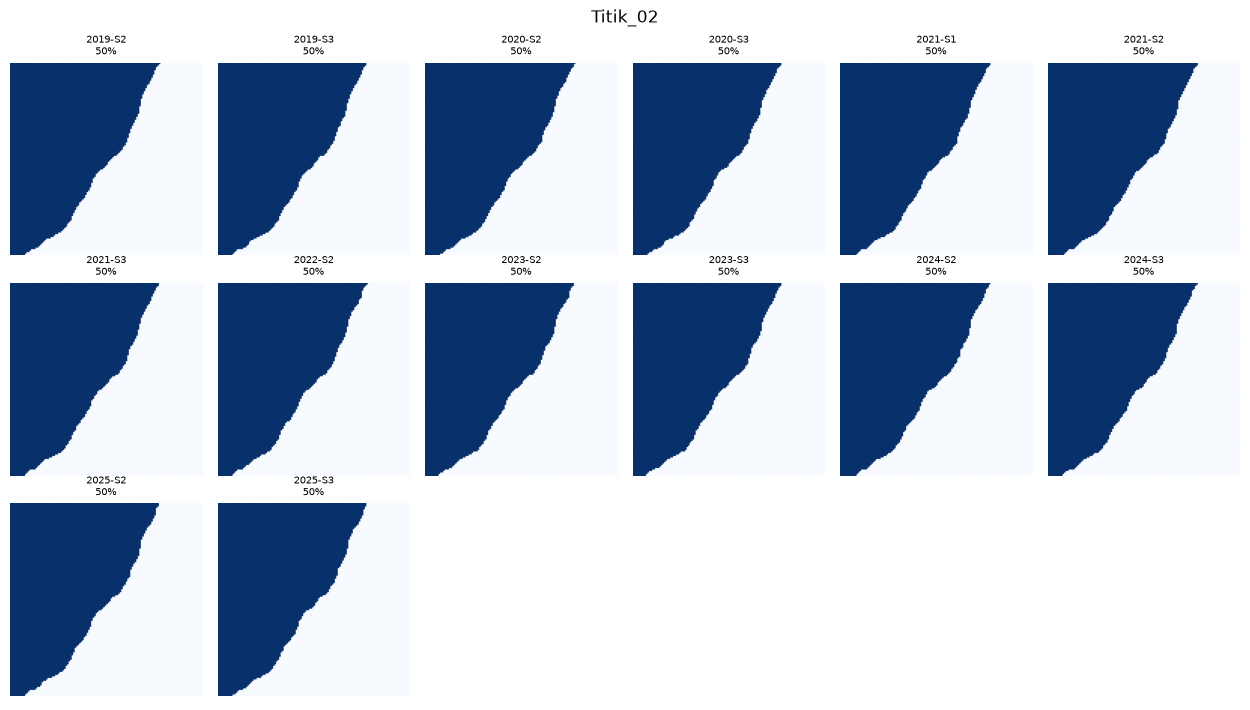

,year,season,water_pct,delta_pp
0,2019,S2,50.103760,NaN
1,2019,S3,49.957275,-0.146484
2,2020,S2,50.079346,0.122070
3,2020,S3,49.755859,-0.323486
4,2021,S1,50.366211,0.610352
5,2021,S2,50.402832,0.036621
6,2021,S3,49.725342,-0.677490
7,2022,S2,49.877930,0.152588
8,2023,S2,49.694824,-0.183105
9,2023,S3,49.530029,-0.164795


In [10]:
orch.show_frames('Titik_02')
orch.water_pct_table('Titik_02')

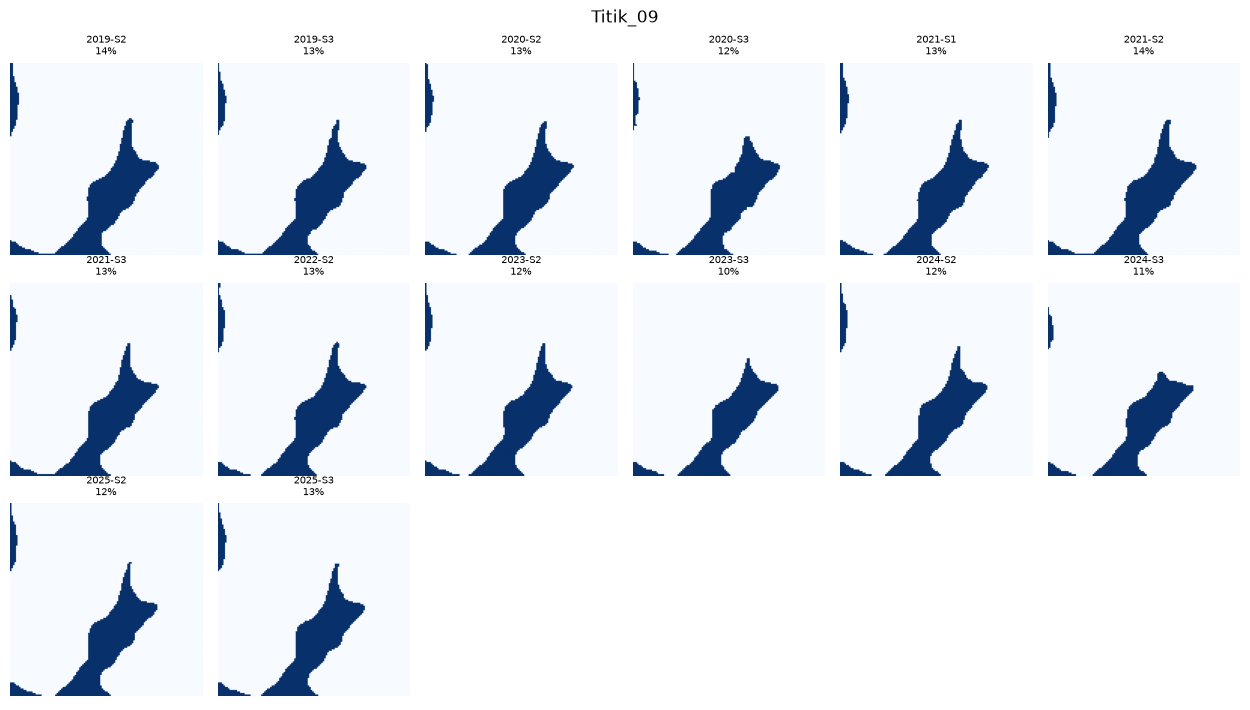

,year,season,water_pct,delta_pp
0,2019,S2,13.745117,NaN
1,2019,S3,13.330078,-0.415039
2,2020,S2,12.915039,-0.415039
3,2020,S3,12.426758,-0.488281
4,2021,S1,13.305664,0.878906
5,2021,S2,13.586426,0.280762
6,2021,S3,12.579346,-1.007080
7,2022,S2,12.792969,0.213623
8,2023,S2,12.451172,-0.341797
9,2023,S3,10.498047,-1.953125


In [12]:
orch.show_frames('Titik_09')
orch.water_pct_table('Titik_09')

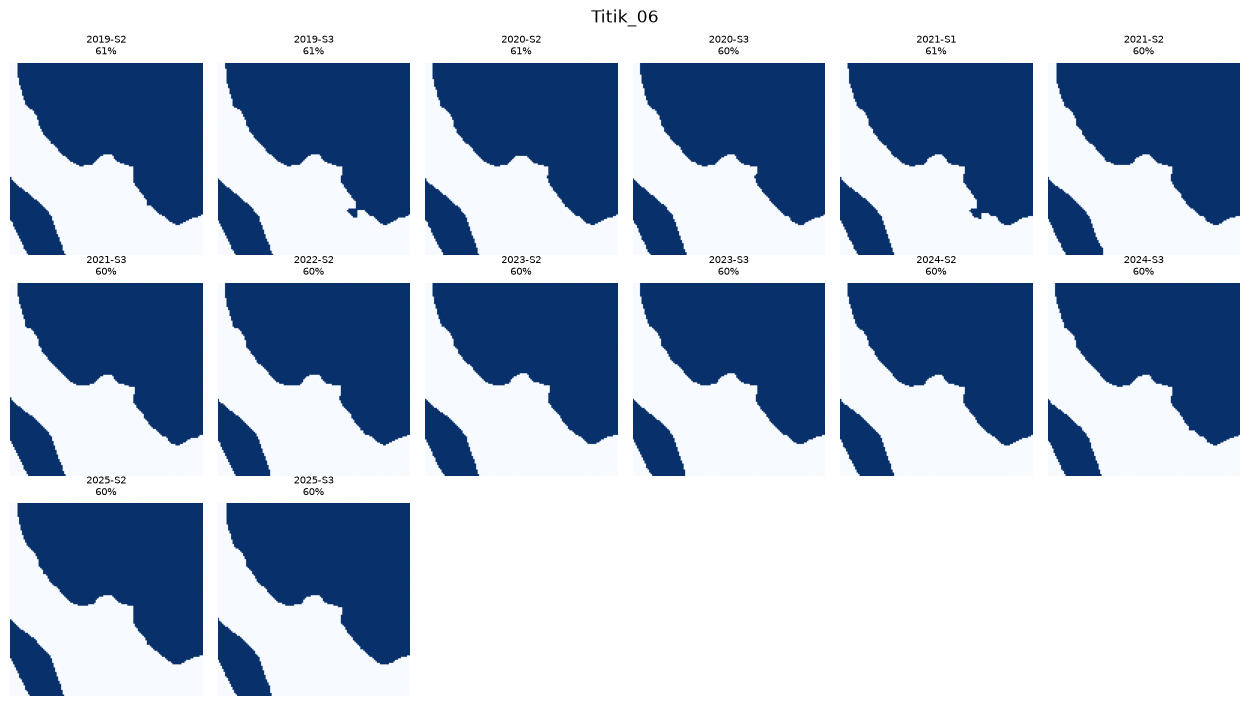

,year,season,water_pct,delta_pp
0,2019,S2,60.632324,NaN
1,2019,S3,60.644531,0.012207
2,2020,S2,60.650635,0.006104
3,2020,S3,60.388184,-0.262451
4,2021,S1,60.858154,0.469971
5,2021,S2,60.394287,-0.463867
6,2021,S3,60.418701,0.024414
7,2022,S2,60.314941,-0.103760
8,2023,S2,59.936523,-0.378418
9,2023,S3,59.832764,-0.103760


In [ ]:
orch.show_frames('Titik_06')
orch.water_pct_table('Titik_06')I

In [15]:
orch.summary()

,threshold,ok,thin,empty,mask_exported
aoi,,,,,
Titik_02,0.0047,14,7,3,14
Titik_07,-0.0554,14,7,3,14
Titik_19,0.4551,14,7,3,14
Titik_04,-0.0863,14,7,3,14
Titik_05,0.0346,15,6,3,15
Titik_06,-0.0449,14,7,3,14
Titik_09,0.0956,14,7,3,14
Titik_10,-0.0150,15,6,3,15
Titik_11,0.0946,15,6,3,15


In [16]:
# ============================================================
# CELL BARU — Adaptive Gap-Fill (inherit, TIDAK re-run instance lama)
# Threshold Otsu di-REUSE dari manifest offline yang udah ada (skip
# fit_threshold ulang). Cuma proses (aoi, tahun, musim) yang BELUM ada.
# CLOUD_FILTER dicoba makin longgar per-slot sampe scene cukup -- dipakai
# level paling ketat yang masih cukup, biar kontaminasi awan minimal.
# ============================================================

ADAPTIVE_CLOUD_STEPS = [20, 35, 50, 70, 90]   # % cloud, makin longgar
ADAPTIVE_MIN_SCENE_FLOOR = 3                  # jangan di bawah ini walau adaptif


class AdaptiveShorelineProcessor(ShorelineProcessor):
    """Subclass isi-gap doang. Threshold di-load, bukan di-fit ulang --
    biar konsisten sama prinsip 'threshold sekali dari ref_year' di
    docstring aslinya (nggak boleh threshold beda per-frame)."""

    @classmethod
    def from_manifest(cls, aoi_name, aoi_manifest):
        p = cls(aoi_name, aoi_manifest['lon'], aoi_manifest['lat'],
                buffer_m=aoi_manifest['buffer_m'])
        p.threshold = ee.Number(aoi_manifest['threshold_otsu'])
        p.threshold_val = aoi_manifest['threshold_otsu']
        return p

    def _collection_cf(self, start, end, cloud_filter):
        s2 = (ee.ImageCollection(S2_SR_COLLECTION)
              .filterBounds(self.aoi).filterDate(start, end)
              .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', cloud_filter)))
        cld = (ee.ImageCollection(S2_CLD_COLLECTION)
               .filterBounds(self.aoi).filterDate(start, end))
        return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(
            primary=s2, secondary=cld,
            condition=ee.Filter.equals(leftField='system:index',
                                       rightField='system:index')))

    def _composite_cf(self, start, end, cloud_filter):
        coll = self._collection_cf(start, end, cloud_filter)
        n = coll.size().getInfo()
        if n == 0:
            return None, 0
        comp = (coll.map(self._mask_clouds).map(self._add_mndwi)
                    .median().clip(self.aoi))
        return comp, n

    def fill_gap_adaptive(self, yr, s_name, seasons=SEASONS,
                           steps=ADAPTIVE_CLOUD_STEPS,
                           min_scene_floor=ADAPTIVE_MIN_SCENE_FLOOR,
                           verbose=True):
        """Naikin CLOUD_FILTER step demi step sampe n_scene >= floor.
        Berhenti di step PALING KETAT yang udah cukup -- dicatat level
        mana yang kepake, biar bisa di-QA belakangan."""
        s_md, e_md = seasons[s_name]
        start, end = f"{yr}-{s_md}", f"{yr}-{e_md}"
        for cf in steps:
            comp, n = self._composite_cf(start, end, cf)
            if comp is not None and n >= min_scene_floor:
                water = self._keep_ocean(self._water_mask(comp))
                self.frames[(yr, s_name)] = {
                    'composite': comp, 'water': water,
                    'edge': self._edge(water), 'n_scene': n,
                    'cloud_filter_used': cf}
                self.meta.append({'year': yr, 'season': s_name, 'n_scene': n,
                                  'status': 'ok_adaptive', 'cloud_filter_used': cf})
                if verbose:
                    tqdm.write(f"  [{self.aoi_name}] {yr}-{s_name}: "
                              f"cf={cf}% -> {n} scene ✓")
                return True
        if verbose:
            tqdm.write(f"  [{self.aoi_name}] {yr}-{s_name}: GAGAL "
                      f"(cloud kebangetan walau cf={steps[-1]}%)")
        self.meta.append({'year': yr, 'season': s_name, 'n_scene': 0,
                          'status': 'empty_adaptive'})
        return False


class AdaptiveShorelineOrchestrator(ShorelineOrchestrator):
    """Reuse offline bundle lama. TIDAK manggil run_all()/fit_threshold()
    -- cuma isi gap yang belum ada, terus merge ke masks lama."""

    def load_and_prepare(self, bundle_dir):
        self.masks, self.manifest = self.load_offline(bundle_dir)
        self.processors = {
            nama: AdaptiveShorelineProcessor.from_manifest(nama, info)
            for nama, info in self.manifest['aoi'].items()
        }
        for nama, info in self.manifest['aoi'].items():
            self.processors[nama]._known = set(
                (int(k.split('_')[0]), k.split('_')[1]) for k in info['frames'])
        print(f"Loaded {len(self.processors)} AOI, threshold di-reuse "
              f"(TIDAK re-fit).")
        return self.processors

    def find_gaps(self, years=YEARS, seasons=SEASON_ORDER):
        gaps = [(nama, yr, s) for nama, p in self.processors.items()
                for yr in years for s in seasons
                if (yr, s) not in p._known]
        total_slot = len(self.processors) * len(years) * len(seasons)
        print(f"Gap ditemukan: {len(gaps)}/{total_slot} slot")
        return gaps

    def fill_all_gaps(self, gaps=None, cooldown_s=COOLDOWN_S):
        gaps = gaps if gaps is not None else self.find_gaps()
        bar = tqdm(gaps, desc="gap-fill", unit="frame")
        n_ok = n_fail = 0
        for nama, yr, s in bar:
            ok = self.processors[nama].fill_gap_adaptive(yr, s, verbose=False)
            n_ok += ok; n_fail += (not ok)
            bar.set_postfix(ok=n_ok, fail=n_fail, refresh=False)
            time.sleep(cooldown_s)
        bar.close()
        print(f"Gap-fill selesai: {n_ok} berhasil, {n_fail} tetep gagal "
              f"(cloud cover ekstrem, bukan solvable via cloud filter doang)")
        return n_ok, n_fail

    def merge_and_save(self, out_dir):
        """export_all() dari class induk otomatis MERGE ke self.masks
        (karena self.masks udah di-preload dari load_and_prepare) --
        jadi tinggal panggil terus simpen manifest+bundle baru."""
        self.export_all()  # cuma download frame baru, cache lama nggak disentuh ulang

        os.makedirs(out_dir, exist_ok=True)
        new_manifest = json.loads(json.dumps(self.manifest))  # deep copy
        for nama, p in self.processors.items():
            for (yr, s), f in p.frames.items():
                new_manifest['aoi'][nama]['frames'][f"{yr}_{s}"] = f['n_scene']
        new_manifest['adaptive_fill'] = {
            'steps_tried': ADAPTIVE_CLOUD_STEPS,
            'min_scene_floor': ADAPTIVE_MIN_SCENE_FLOOR,
            'filled_utc': pd.Timestamp.utcnow().isoformat(),
        }
        with open(os.path.join(out_dir, "manifest.json"), "w") as f:
            json.dump(new_manifest, f, indent=2)
        for nama, frames in self.masks.items():
            arrays = {f"{k[0]}_{k[1]}": v for k, v in frames.items()}
            np.savez_compressed(os.path.join(out_dir, f"{nama}_masks.npz"), **arrays)
        print(f"Bundle adaptif (lama+baru merged) tersimpan: {out_dir}")
        return out_dir

In [17]:
# ============================================================
# JALANIN gap-fill adaptif -- reuse bundle offline yang udah ada
# ============================================================

OLD_BUNDLE = os.path.join(TENSOR_DIR, "offline")       # bundle export_offline() lama
NEW_BUNDLE = os.path.join(TENSOR_DIR, "offline_adaptive")

aorch = AdaptiveShorelineOrchestrator()
aorch.load_and_prepare(OLD_BUNDLE)

gaps = aorch.find_gaps()
aorch.fill_all_gaps(gaps)

aorch.merge_and_save(NEW_BUNDLE)

# ringkasan cloud_filter yang kepake per frame baru (buat QA)
rows = [{'aoi': nama, 'year': yr, 'season': s, 'n_scene': f['n_scene'],
        'cloud_filter_used': f['cloud_filter_used']}
        for nama, p in aorch.processors.items()
        for (yr, s), f in p.frames.items()]
pd.DataFrame(rows).sort_values(['aoi', 'year', 'season'])


Loaded 9 AOI dari ../data/tensors\offline (dibuat 2026-07-16)
Loaded 9 AOI, threshold di-reuse (TIDAK re-fit).
Gap ditemukan: 87/216 slot


gap-fill:   0%|          | 0/87 [00:00<?, ?frame/s]

Gap-fill selesai: 78 berhasil, 9 tetep gagal (cloud cover ekstrem, bukan solvable via cloud filter doang)


export:   0%|          | 0/78 [00:00<?, ?mask/s]

✗ Titik_11 2022-S3 GAGAL: ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
✓ Titik_02   9 baru, 0 dari cache
✓ Titik_07   9 baru, 0 dari cache
✓ Titik_19   9 baru, 0 dari cache
✓ Titik_04   9 baru, 0 dari cache
✓ Titik_05   8 baru, 0 dari cache
✓ Titik_06   9 baru, 0 dari cache
✓ Titik_09   9 baru, 0 dari cache
✓ Titik_10   8 baru, 0 dari cache
✓ Titik_11   7 baru, 0 dari cache
Bundle adaptif (lama+baru merged) tersimpan: ../data/tensors\offline_adaptive


C:\Users\Loq Gaming\AppData\Local\Temp\ipykernel_24276\1393227099.py:130: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'filled_utc': pd.Timestamp.utcnow().isoformat(),


,aoi,year,season,n_scene,cloud_filter_used
0,Titik_02,2018,S2,3,20
1,Titik_02,2018,S3,3,90
2,Titik_02,2019,S1,6,35
3,Titik_02,2020,S1,4,20
4,Titik_02,2022,S1,7,35
...,...,...,...,...,...
22,Titik_19,2022,S1,7,35
23,Titik_19,2022,S3,5,35
24,Titik_19,2023,S1,3,20
25,Titik_19,2024,S1,3,20


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

# Kustom Metrik Dice Coefficient untuk memantau performa sesuai paper
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def build_convlstm_net(img_shape=(128, 128, 4), timesteps=3):
    inputs = layers.Input(shape=(timesteps, img_shape[0], img_shape[1], img_shape[2]))
    
    # --- ENCODER LAYER (Spatiotemporal Feature Extraction) ---
    # Blok 1: ConvLSTM awal -> Resolusi tetap 128x128
    enc1 = layers.ConvLSTM2D(32, (3, 3), padding='same', return_sequences=True, activation='tanh')(inputs)
    enc1_bn = layers.BatchNormalization()(enc1)
    pool1 = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(enc1_bn) # Downsample ke 64x64
    
    # Blok 2: ConvLSTM kedua -> Resolusi menjadi 64x64
    enc2 = layers.ConvLSTM2D(64, (3, 3), padding='same', return_sequences=True, activation='tanh')(pool1)
    enc2_bn = layers.BatchNormalization()(enc2)
    pool2 = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(enc2_bn) # Downsample ke 32x32
    
    # --- BOTTLENECK ---
    # Mengompresi dimensi waktu (return_sequences=False) untuk memprediksi single-frame target (t+1)
    bottleneck = layers.ConvLSTM2D(128, (3, 3), padding='same', return_sequences=False, activation='tanh')(pool2)
    bottleneck_bn = layers.BatchNormalization()(bottleneck) # Shape: (32, 32, 128)
    
    # --- DECODER LAYER dengan U-Net Skip Connections ---
    # Karena dimensi waktu sudah dikompresi di bottleneck, Decoder menggunakan elemen 2D standar
    
    # Collapse / Ambil frame terakhir dari Encoder untuk Skip Connection agar berdimensi 2D
    skip2 = layers.Lambda(lambda x: x[:, -1, :, :, :])(enc2_bn) # Shape: (64, 64, 64)
    skip1 = layers.Lambda(lambda x: x[:, -1, :, :, :])(enc1_bn) # Shape: (128, 128, 32)
    
    # Up-Blok 1: Resolusi dari 32x32 -> 64x64
    up1 = layers.UpSampling2D((2, 2))(bottleneck_bn)
    concat1 = layers.Concatenate()([up1, skip2])
    dec1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(concat1)
    
    # Up-Blok 2: Resolusi dari 64x64 -> 128x128
    up2 = layers.UpSampling2D((2, 2))(dec1)
    concat2 = layers.Concatenate()([up2, skip1])
    dec2 = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(concat2)
    
    # Output Layer (Binary Segmentation Mask untuk Water/Land)
    outputs = layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid', name='water_mask_output')(dec2)
    
    model = models.Model(inputs, outputs, name="Boen_Et_Al_ConvLSTM_Net")
    
    # Compile Menggunakan Adam + Binary Crossentropy + Metrik Evaluasi Paper
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', dice_coefficient, tf.keras.metrics.OneHotMeanIoU(num_classes=2)]
    )
    
    return model

# Inisialisasi Model
model_convlstm_net = build_convlstm_net(img_shape=(128, 128, 4), timesteps=LOOKBACK_YEARS)
model_convlstm_net.summary()

import os
import numpy as np
import matplotlib.pyplot as plt
import datetime
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard

# 1. Chronological Split (Train vs Test)
split_idx = -2 

X_train_split = X_train[:split_idx]
Y_train_split = Y_train[:split_idx]

X_test_split = X_train[split_idx:]
Y_test_split = Y_train[split_idx:]

print("=== DATA SPLIT (KRONOLOGIS) ===")
print(f"Train Shape: X={X_train_split.shape}, Y={Y_train_split.shape} (Target 2018-2023)")
print(f"Test Shape : X={X_test_split.shape}, Y={Y_test_split.shape} (Target 2024-2025)\n")

# 2. Setup Logging & Callbacks
# Bikin folder log khusus buat AOI ini yang ada timestamp-nya
log_dir = os.path.join(OUTPUT_DIR, "logs", TARGET_AOI, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint(filepath=os.path.join(OUTPUT_DIR, f'best_convlstm_{TARGET_AOI}.h5'), save_best_only=True),
    TensorBoard(log_dir=log_dir, histogram_freq=1, write_graph=True) # Aktifin TensorBoard
]

print(f"=== MEMULAI TRAINING UNTUK {TARGET_AOI} ===")
print(f"Log TensorBoard tersimpan di: {log_dir}\n")

# JALANKAN TENSORBOARD DI DALAM NOTEBOOK
# Hapus tanda pagar (#) di bawah ini kalau lu jalanin di Jupyter/Colab biar UI-nya muncul
%load_ext tensorboard
%tensorboard --logdir "{os.path.join(OUTPUT_DIR, 'logs', TARGET_AOI)}"

# 3. Gas Training!
history = model_convlstm_net.fit(
    X_train_split, Y_train_split,
    validation_data=(X_test_split, Y_test_split),
    epochs=50,          # Bebas dinaikin kalau val_loss masih ada tren turun
    batch_size=2,       
    callbacks=callbacks,
    verbose=1
)

print("\n=== TRAINING SELESAI! MENAMPILKAN VISUALISASI METRIK ===")

# 4. Plot Visualisasi Metrik Akhir (Matplotlib)
plt.figure(figsize=(15, 5))

# A. Plot Loss (Binary Crossentropy)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (BCE)', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss (BCE)', marker='o')
plt.title(f'Model Loss - {TARGET_AOI}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# B. Plot Dice Coefficient (Akurasi Area Segmentasi)
plt.subplot(1, 2, 2)
# Keras menyimpan nama metrik custom sesuai nama fungsinya, yaitu 'dice_coefficient'
plt.plot(history.history['dice_coefficient'], label='Train Dice', marker='s')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice', marker='s')
plt.title(f'Dice Coefficient (Target ~99%) - {TARGET_AOI}')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import datetime
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard

# 1. Chronological Split (Train vs Test)
split_idx = -2 

X_train_split = X_train[:split_idx]
Y_train_split = Y_train[:split_idx]

X_test_split = X_train[split_idx:]
Y_test_split = Y_train[split_idx:]

print("=== DATA SPLIT (KRONOLOGIS) ===")
print(f"Train Shape: X={X_train_split.shape}, Y={Y_train_split.shape} (Target 2018-2023)")
print(f"Test Shape : X={X_test_split.shape}, Y={Y_test_split.shape} (Target 2024-2025)\n")

# 2. Setup Logging & Callbacks
# Bikin folder log khusus buat AOI ini yang ada timestamp-nya
log_dir = os.path.join(OUTPUT_DIR, "logs", TARGET_AOI, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint(filepath=os.path.join(OUTPUT_DIR, f'best_convlstm_{TARGET_AOI}.h5'), save_best_only=True),
    TensorBoard(log_dir=log_dir, histogram_freq=1, write_graph=True) # Aktifin TensorBoard
]

print(f"=== MEMULAI TRAINING UNTUK {TARGET_AOI} ===")
print(f"Log TensorBoard tersimpan di: {log_dir}\n")

# JALANKAN TENSORBOARD DI DALAM NOTEBOOK
# Hapus tanda pagar (#) di bawah ini kalau lu jalanin di Jupyter/Colab biar UI-nya muncul
%load_ext tensorboard
%tensorboard --logdir "{os.path.join(OUTPUT_DIR, 'logs', TARGET_AOI)}"

# 3. Gas Training!
history = model_convlstm_net.fit(
    X_train_split, Y_train_split,
    validation_data=(X_test_split, Y_test_split),
    epochs=50,          # Bebas dinaikin kalau val_loss masih ada tren turun
    batch_size=2,       
    callbacks=callbacks,
    verbose=1
)

print("\n=== TRAINING SELESAI! MENAMPILKAN VISUALISASI METRIK ===")

# 4. Plot Visualisasi Metrik Akhir (Matplotlib)
plt.figure(figsize=(15, 5))

# A. Plot Loss (Binary Crossentropy)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (BCE)', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss (BCE)', marker='o')
plt.title(f'Model Loss - {TARGET_AOI}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# B. Plot Dice Coefficient (Akurasi Area Segmentasi)
plt.subplot(1, 2, 2)
# Keras menyimpan nama metrik custom sesuai nama fungsinya, yaitu 'dice_coefficient'
plt.plot(history.history['dice_coefficient'], label='Train Dice', marker='s')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice', marker='s')
plt.title(f'Dice Coefficient (Target ~99%) - {TARGET_AOI}')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PART 1: PREDIKSI & EVALUASI DATA TEST (2024 - 2025)
# ==========================================
print("=== MENGEVALUASI MODEL PADA DATA TEST ===")
# Jalankan prediksi pada data test
Y_pred_test = model_convlstm_net.predict(X_test_split)

# Binerisasi hasil prediksi sigmoid (0-1) menjadi mask tegas (0 atau 1)
# Piksel > 0.5 dianggap Air (1.0), sisanya Darat (0.0)
Y_pred_biner = np.where(Y_pred_test > 0.5, 1.0, 0.0)

test_years = [2024, 2025]

# Set up canvas untuk visualisasi evaluasi
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Evaluasi Model ConvLSTM-Net ({TARGET_AOI}) - Real vs Prediksi", fontsize=16, fontweight='bold')

for i in range(2):
    # Kolom 1: MNDWI tahun sebelumnya (sebagai referensi input terakhir)
    ax1 = axes[i, 0]
    # Indeks 3 adalah channel MNDWI
    ax1.imshow(X_test_split[i, -1, ..., 3], cmap='coolwarm') 
    ax1.set_title(f"MNDWI Input (Tahun {test_years[i]-1})", fontsize=12)
    ax1.axis('off')
    
    # Kolom 2: Ground Truth (Water Mask Sebenarnya)
    ax2 = axes[i, 1]
    ax2.imshow(Y_test_split[i, ..., 0], cmap='Blues')
    ax2.set_title(f"Target Asli (Water Mask {test_years[i]})", fontsize=12)
    ax2.axis('off')
    
    # Kolom 3: Hasil Prediksi Model
    ax3 = axes[i, 2]
    ax3.imshow(Y_pred_biner[i, ..., 0], cmap='Blues')
    ax3.set_title(f"Prediksi Model ({test_years[i]})", fontsize=12)
    ax3.axis('off')

plt.tight_layout()
plt.show()


# ==========================================
# PART 2: FORECASTING MASA DEPAN (2026 - 2028)
# ==========================================
print("\n=== MELAKUKAN PROYEKSI MASA DEPAN (2026 - 2028) ===")

future_years = [2026, 2027, 2028]
future_predictions = []

# Ambil sekuens 3 tahun terakhir dari data asli (2023, 2024, 2025) sebagai modal awal
current_sequence = X_all[-3:].copy() 

for year in future_years:
    # 1. Prediksi frame tahun berikutnya (tambahkan dimensi batch di depan)
    pred_prob = model_convlstm_net.predict(np.expand_dims(current_sequence, axis=0))[0]
    pred_mask = np.where(pred_prob > 0.5, 1.0, 0.0) # Jadikan biner 0 atau 1
    future_predictions.append(pred_mask)
    
    # 2. Rekonstruksi frame baru untuk sliding window berikutnya
    # Ambil background RGB dari tahun terakhir (2025) agar konstan
    last_rgb = current_sequence[-1, ..., :3]  # Shape: (128, 128, 3)
    
    # Tempelkan hasil prediksi water mask sebagai channel ke-4 (pengganti MNDWI)
    new_frame = np.concatenate([last_rgb, pred_mask], axis=-1) # Shape: (128, 128, 4)
    
    # 3. Geser window: Buang tahun tertua (indeks 0), masukkan frame hasil prediksi baru di akhir
    current_sequence = np.concatenate([current_sequence[1:], np.expand_dims(new_frame, axis=0)], axis=0)

# Set up canvas untuk visualisasi masa depan
fig_future, axes_future = plt.subplots(1, 3, figsize=(15, 5))
fig_future.suptitle(f"Proyeksi Garis Pantai Masa Depan ({TARGET_AOI}) - Autoregressive Loop", fontsize=16, fontweight='bold')

for i, year in enumerate(future_years):
    ax = axes_future[i]
    ax.imshow(future_predictions[i][..., 0], cmap='Blues_r') # Blues_r biar kontras darat-lautnya enak dilihat
    ax.set_title(f"Estimasi Water Mask ({year})", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()